# Stage 02: Data pipeline

**Input:** three public floor-plan datasets, each in its own format.
**Output:** one common representation, a structural column arrangement plus
~20 geometric features per plan, collected in `data/features_all.csv`.

An architectural drawing does not record a structural column layout. This
stage **derives** one, by a stated procedure:

1. **Discard every wall thinner than 160 mm.** That is the minimum thickness
   for a 2-hour fire rating, so anything below it is a partition rather than
   primary structure.
2. **Build the grid from the surviving load-bearing walls only.** A
   structural grid should be defined by structural elements; using every wall
   puts grid lines at partition spacing instead of bay spacing.
3. **Place a column at every grid node that physically lies inside one of
   those walls**, testing containment against each wall's start point, end
   point and thickness.
4. **Add every column the drawing explicitly annotates**, whether or not it
   falls inside a wall.

### What this is, and is not

Steps 1 to 3 are an **equivalent-frame idealisation of a wall-bearing
structure**, not a recovered column layout. These buildings do not have a
column grid to recover. Badoux and Peter, surveying 50+ Swiss buildings from
original construction drawings, report that in the dominant Swiss apartment
type *"the partition walls are structural bearing walls"* and that
*"frame-type structural systems are an exception"*. The corpus agrees: its
wall-area index is about 24%, against roughly 15% for shear-wall buildings
and 8% for reinforced concrete frames in published benchmarks. Nearly every
wall carries load, so the filter selects the *primary* walls rather than
separating structure from non-structure.

Only step 4 is observed. The rest is a modelling decision, recorded here so
the two are never conflated.

### Where the 160 mm comes from

| Source | Figure |
|---|---|
| Eurocode 2, minimum for a reinforced load-bearing wall | 140 mm |
| Badoux and Peter, thinnest r.c. wall in the Swiss stock | 140 mm |
| DISCS, 10th percentile over 102 real Swiss buildings | 140-150 mm |
| **2-hour fire rating minimum, the value used** | **160 mm** |
| DISCS median structural wall, interior and peripheral alike | 200 mm |

### What each source supports

| Source | Per-wall thickness | Annotated columns | `confidence` |
|---|---|---|---|
| Swiss Dwellings | yes, in metres | yes | `verified` |
| CubiCasa5K | yes, but in pixels of unknown scale | yes | `relative-scale` |
| ResPlan | no, one `wall_depth` per plan | no | `none` |

CubiCasa carries no real-world scale, so an absolute millimetre cutoff is
impossible there and a per-plan relative quantile is used instead. ResPlan
supports neither step 1 nor step 4, so it stays on the legacy
every-intersection path and is kept for descriptive statistics only. It is
excluded from every training set.

The raw datasets are large downloads and are not committed; the extracted
feature table is. Set the paths in section 5 to regenerate it.

In [1]:
# Imports. Geometry is numpy, SVG parsing is the standard library. shapely is
# used for two things only: unpickling ResPlan, and measuring wall thickness
# from the wall polygons in Swiss and CubiCasa.
import json
import re
import xml.etree.ElementTree as ET
import zipfile
from hashlib import md5
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Polygon

sns.set_theme(style="whitegrid", context="notebook")
DATA = Path("..") / "data"
FIGS = Path("..") / "figures"

## 1. Conversion core

Rotate the plan onto the axes, then cluster wall positions into grid lines.

The rotation matters because Swiss plans are drawn at arbitrary angles. Walls
come in perpendicular pairs, so angles are folded modulo 90 degrees with the
$4\theta$ trick: take the length-weighted mean of $e^{4i\theta}$, and its
argument over four is the dominant wall direction.

`grid_lines` returns the lines together with the rotation and tolerance it
used, because the ground-truth step in section 2 needs both to test wall
containment in the same frame.

In [2]:
# The dominant wall direction of a plan, and the rotation that puts it on the
# axes. Kept as two functions because the ground-truth step has to rotate
# walls and annotated columns into the same frame as the grid.
def dominant_angle(segs):
    dx, dy = segs[:, 2] - segs[:, 0], segs[:, 3] - segs[:, 1]
    length = np.hypot(dx, dy)
    angle = np.arctan2(dy, dx)
    return np.angle(np.sum(length * np.exp(4j * angle))) / 4


def rotate_segments(segs, rotation):
    if abs(np.degrees(rotation)) < 1.0:
        return segs                                   # already axis-aligned
    c, s = np.cos(-rotation), np.sin(-rotation)
    R = np.array([[c, -s], [s, c]])
    return np.hstack([segs[:, :2] @ R.T, segs[:, 2:] @ R.T])


def rotate_points(points, rotation):
    points = np.asarray(points, float)
    if len(points) == 0 or abs(np.degrees(rotation)) < 1.0:
        return points
    c, s = np.cos(-rotation), np.sin(-rotation)
    return points @ np.array([[c, -s], [s, c]]).T


def align_to_axes(segs):
    # Back-compat wrapper: rotate segments onto the dominant direction.
    return rotate_segments(segs, dominant_angle(segs))

In [3]:
# Weighted 1-D clustering, the same routine the plan parser uses in stage 04.
def cluster_lines(values, weights, tol):
    if len(values) == 0:
        return np.array([])
    order = np.argsort(values)
    v, w = np.asarray(values)[order], np.asarray(weights)[order]
    cut = np.flatnonzero(np.diff(v) > tol) + 1
    return np.array([np.average(c, weights=wc)
                     for c, wc in zip(np.split(v, cut), np.split(w, cut))])

In [4]:
# Wall segments -> grid lines, plus the rotation and tolerance used. Only
# walls within 10 degrees of an axis vote for a line; anything more inclined
# would put a line where no wall is. Tolerances are fractions of the plan
# size, so the same numbers work for decimetres, metres and SVG pixels alike.
def grid_lines(segs, tol_frac=0.015, min_len_frac=0.05):
    segs = np.asarray(segs, float)
    if len(segs) == 0:
        return None, None, 0.0, 0.0
    rotation = dominant_angle(segs)
    segs = rotate_segments(segs, rotation)

    dx, dy = segs[:, 2] - segs[:, 0], segs[:, 3] - segs[:, 1]
    all_x = np.r_[segs[:, 0], segs[:, 2]]
    all_y = np.r_[segs[:, 1], segs[:, 3]]
    span = max(all_x.max() - all_x.min(), all_y.max() - all_y.min())
    if span <= 0:
        return None, None, 0.0, 0.0
    tol, min_len = tol_frac * span, min_len_frac * span

    angle = np.degrees(np.arctan2(np.abs(dy), np.abs(dx)))
    vertical, horizontal = angle >= 80, angle <= 10
    long_enough = np.where(vertical, np.abs(dy), np.abs(dx)) >= min_len

    v, h = vertical & long_enough, horizontal & long_enough
    x_lines = cluster_lines((segs[v, 0] + segs[v, 2]) / 2, np.abs(dy[v]), tol)
    y_lines = cluster_lines((segs[h, 1] + segs[h, 3]) / 2, np.abs(dx[h]), tol)
    if len(x_lines) < 2 or len(y_lines) < 2:
        return None, None, 0.0, 0.0
    return x_lines, y_lines, rotation, tol


# Legacy path: a column at EVERY intersection. Used only for ResPlan, which
# supports neither the thickness filter nor annotated columns, and for the
# stage 04 parser demo further down. Not the ground truth.
def parse_walls(segs, tol_frac=0.015, min_len_frac=0.05):
    x_lines, y_lines, _, _ = grid_lines(segs, tol_frac, min_len_frac)
    if x_lines is None:
        return None
    return np.array([(round(float(x), 2), round(float(y), 2))
                     for x in x_lines for y in y_lines])

## 2. The structural ground truth

The four steps from the header, in code. `wall_centreline` turns a wall
polygon into a centreline plus a thickness, which is what makes step 1
possible at all: both Swiss and CubiCasa store walls as real polygons with
width, not as bare centrelines.

`nodes_in_walls` is step 3 and is the part worth reading closely. It tests
that a node falls **between the wall's two ends** along its length *and*
within half the thickness across it. A short wall therefore claims only the
nodes it actually reaches. Testing the grid line alone would let a stub wall
at one end of the building mark nodes at the far end.

In [5]:
# The ground-truth parameter. See the table in the header for where it comes
# from. Everything below DEGENERATE_MIN is drawing noise, not a wall.
LB_THICKNESS_MIN = 0.160      # metres, 2-hour fire rating minimum
DEGENERATE_MIN = 0.050        # metres


# A wall polygon -> (x1, y1, x2, y2, thickness). The centreline runs between
# the midpoints of the two short edges of the tightest enclosing rectangle,
# and the thickness is the short edge itself.
def wall_centreline(ring):
    try:
        poly = Polygon(ring)
        if (not poly.is_valid) or poly.area <= 0:
            return None
        box = np.asarray(poly.minimum_rotated_rectangle.exterior.coords)
    except Exception:
        return None
    if len(box) < 5:
        return None
    edges = box[1:] - box[:-1]
    lengths = np.hypot(edges[:, 0], edges[:, 1])
    if lengths.max() < 1e-9:
        return None
    short = (int(np.argmax(lengths)) + 1) % 4
    thickness = float(lengths[short])
    a = (box[short] + box[short + 1]) / 2
    b = (box[(short + 2) % 4] + box[(short + 3) % 4]) / 2
    return float(a[0]), float(a[1]), float(b[0]), float(b[1]), thickness

In [6]:
# Step 1. Which walls carry load? Swiss is in metres so an absolute cutoff
# applies. CubiCasa is in pixels of unknown scale, so it falls back to a
# per-plan quantile of that plan's own thicknesses.
def load_bearing(walls, mode="absolute",
                 threshold=LB_THICKNESS_MIN, quantile=0.6):
    if not walls:
        return []
    w = np.asarray(walls, float)
    w = w[w[:, 4] >= DEGENERATE_MIN]
    if len(w) == 0:
        return []
    cut = threshold if mode == "absolute" else np.quantile(w[:, 4], quantile)
    return w[w[:, 4] >= cut].tolist()


# Step 3. Which grid nodes lie physically inside one of these walls? For each
# wall: project every node onto the wall direction (must land between the two
# ends, with a half-thickness overhang so corner joints are not missed) and
# onto its perpendicular (must be within half the thickness).
def nodes_in_walls(x_lines, y_lines, walls, rotation, slack=0.0):
    nodes = np.array([(x, y) for x in x_lines for y in y_lines])
    inside = np.zeros(len(nodes), bool)
    if not walls or len(nodes) == 0:
        return nodes, inside
    w = np.asarray(walls, float)
    start = rotate_points(w[:, :2], rotation)
    end = rotate_points(w[:, 2:4], rotation)
    thickness = w[:, 4]

    for k in range(len(w)):
        dx, dy = end[k] - start[k]
        length = np.hypot(dx, dy)
        if length < 1e-9:
            continue
        rx, ry = nodes[:, 0] - start[k, 0], nodes[:, 1] - start[k, 1]
        along = (rx * dx + ry * dy) / length ** 2          # 0 to 1 down the wall
        across = np.abs(rx * dy - ry * dx) / length        # off the centreline
        overhang = (thickness[k] / 2) / length
        inside |= ((along >= -overhang) & (along <= 1 + overhang) &
                   (across <= thickness[k] / 2 + slack))
    return nodes, inside

In [7]:
# Steps 2 and 4 together: grid from the load-bearing walls only, columns at
# the contained nodes, then union with the annotated columns. An annotated
# column is kept even when it sits nowhere near a wall, because it is real.
def derive_arrangement(walls_lb, annotated):
    if len(walls_lb) < 2:
        return None
    x_lines, y_lines, rotation, tol = grid_lines(
        [[w[0], w[1], w[2], w[3]] for w in walls_lb])
    if x_lines is None:
        return None

    nodes, inside = nodes_in_walls(x_lines, y_lines, walls_lb, rotation, tol)
    derived = nodes[inside]

    columns = derived.copy() if len(derived) else np.empty((0, 2))
    if annotated:
        for x, y in rotate_points(annotated, rotation):
            far = (len(columns) == 0 or
                   np.hypot(columns[:, 0] - x, columns[:, 1] - y).min() > tol * 3)
            if far:
                columns = (np.vstack([columns, [[x, y]]]) if len(columns)
                           else np.array([[x, y]]))
    if len(columns) == 0:
        return None
    return (x_lines, y_lines,
            np.unique(np.round(derived, 2), axis=0) if len(derived) else derived,
            np.unique(np.round(columns, 2), axis=0))

## 2. Feature set

Roughly twenty descriptors per arrangement, split deliberately into two
groups: **absolute** ones (footprints, spans, area, comparable only within
a source, because the units differ) and **scale-invariant** ones (ratios and
coefficients of variation, the only ones any cross-source model may use).

In [8]:
# Geometry descriptors of one arrangement.
def rich_features(columns):
    c = np.asarray(columns, float)
    xl, yl = np.unique(c[:, 0]), np.unique(c[:, 1])
    if len(xl) < 2 or len(yl) < 2:
        return None
    sx, sy = np.diff(xl), np.diff(yl)
    fx, fy = xl[-1] - xl[0], yl[-1] - yl[0]
    n = len(c)
    cov = lambda s: float(s.std() / s.mean()) if s.mean() else 0.0
    on_edge = ((c[:, 0] == xl[0]) | (c[:, 0] == xl[-1]) |
               (c[:, 1] == yl[0]) | (c[:, 1] == yl[-1]))
    perimeter = int(on_edge.sum())

    return {
        # counts and absolute size, within-source only
        "n_columns": n, "n_lines_x": len(xl), "n_lines_y": len(yl),
        "footprint_x": fx, "footprint_y": fy, "area": fx * fy,
        "span_x_mean": sx.mean(), "span_x_min": sx.min(),
        "span_x_max": sx.max(), "span_x_std": sx.std(),
        "span_y_mean": sy.mean(), "span_y_min": sy.min(),
        "span_y_max": sy.max(), "span_y_std": sy.std(),
        "cols_per_karea": n / (fx * fy / 1000),
        # scale-invariant, safe across sources
        "aspect_ratio": fx / fy,
        "cov_x": cov(sx), "cov_y": cov(sy),
        "regularity": 1 / (1 + cov(sx) + cov(sy)),
        "perimeter_cols": perimeter, "interior_cols": n - perimeter,
        "interior_ratio": (n - perimeter) / n,
        "span_ratio_xy": float(sx.mean() / sy.mean()) if sy.mean() else 0.0,
    }

## 3. Deduplication

Multi-storey buildings repeat the same floor plate many times over, and
different plans can describe identical geometry. Arrangements are hashed
after being translated to the origin and rounded, so identical layouts
collapse into one regardless of where they sit in their drawing.

In [9]:
# Translation-invariant hash of an arrangement.
def geometry_hash(columns):
    c = np.asarray(columns, float)
    c = np.round(c - c.min(axis=0), 1)
    c = c[np.lexsort((c[:, 1], c[:, 0]))]
    return md5(c.tobytes()).hexdigest()

In [10]:
# Drive a loader through the ground truth -> features -> dedup and collect the
# rows. A loader yields either a dict (walls with thickness plus annotated
# columns, the ground-truth path) or a bare segment list (the legacy path,
# ResPlan only). `confidence` records which path a row came from, and every
# downstream stage filters on it.
def convert_dataset(name, loader, lb_mode=None, confidence="verified",
                    lb_quantile=0.6, limit=None, report_every=2000):
    seen, rows = set(), []
    scanned = dropped = duplicated = 0
    for entry_id, payload in loader:
        scanned += 1

        if isinstance(payload, dict) and lb_mode is not None:
            walls_lb = load_bearing(payload["walls"], lb_mode,
                                    LB_THICKNESS_MIN, lb_quantile)
            derived = derive_arrangement(walls_lb, payload.get("columns") or [])
            if derived is None:
                dropped += 1
                continue
            _, _, only_derived, cols = derived
            row_confidence = confidence
            n_annotated = len(payload.get("columns") or [])
            n_lb = len(walls_lb)
        else:
            segs = payload["walls_raw"] if isinstance(payload, dict) else payload
            cols = parse_walls(segs)
            if cols is None:
                dropped += 1
                continue
            only_derived, row_confidence, n_annotated, n_lb = cols, "none", 0, 0

        if len(cols) < 4:
            dropped += 1
            continue
        h = geometry_hash(cols)
        if h in seen:
            duplicated += 1
            continue
        seen.add(h)
        feats = rich_features(cols)
        if feats is None:
            dropped += 1
            continue

        rows.append({"source": name, "id": entry_id,
                     "confidence": row_confidence,
                     "n_load_bearing_walls": n_lb,
                     "n_annotated_columns": n_annotated,
                     "n_derived_columns": len(only_derived),
                     **feats})
        if report_every and scanned % report_every == 0:
            print(f"  [{name}] scanned {scanned}, kept {len(rows)}")
        if limit and len(rows) >= limit:
            break
    print(f"[{name}] kept {len(rows)} of {scanned} "
          f"({duplicated} duplicates, {dropped} unusable), confidence={confidence}")
    return pd.DataFrame(rows)

## 4. Source loaders

Each loader is a generator yielding `(entry_id, wall_segments)`. Point the
paths at your local copies of the archives to regenerate the corpus.

In [11]:
# Swiss Dwellings: geometries.csv, entity_type "separator". Subtype "WALL"
# gives the wall polygons, subtype "COLUMN" gives the annotated columns of
# step 4. Read in chunks, the CSV is far larger than memory. Rows are grouped
# by plan_id so repeated floor plates of one building collapse to a single
# plate before dedup even runs.
#
# Each wall polygon is reduced to a centreline plus a thickness, which is what
# the 160 mm filter needs. The raw segments are kept too, so a plan can still
# fall back to the legacy path if no load-bearing wall survives.
def parse_wkt_polygon(text):
    """WKT POLYGON / MULTIPOLYGON -> list of coordinate rings."""
    rings = []
    for ring in re.findall(r"\(([-\d\.,\s]+)\)", text):
        pts = [p.split() for p in ring.split(",") if p.strip()]
        xy = np.array([[float(a), float(b)] for a, b in pts])
        if len(xy) > 1:
            rings.append(xy)
    return rings


def load_swiss(zip_path, inner="swiss-dwellings-v3.0.0/geometries.csv"):
    z = zipfile.ZipFile(zip_path)
    cols = ["plan_id", "entity_type", "entity_subtype", "geometry"]
    plans = {}
    for chunk in pd.read_csv(z.open(inner), usecols=cols, chunksize=400_000):
        rows = chunk[(chunk.entity_type == "separator") &
                     (chunk.entity_subtype.isin(["WALL", "COLUMN"]))]
        for pid, subtype, wkt in zip(rows.plan_id.values,
                                     rows.entity_subtype.values,
                                     rows.geometry.values):
            plan = plans.setdefault(int(pid),
                                    {"walls": [], "columns": [], "walls_raw": []})
            for xy in parse_wkt_polygon(str(wkt)):
                if subtype == "WALL":
                    plan["walls_raw"].extend(
                        [[a[0], a[1], b[0], b[1]] for a, b in zip(xy, xy[1:])])
                    line = wall_centreline(xy)
                    if line is not None:
                        plan["walls"].append(line)
                else:
                    plan["columns"].append([float(xy[:, 0].mean()),
                                            float(xy[:, 1].mean())])
    yield from plans.items()

In [12]:
# CubiCasa5K: each model.svg marks walls as <g class="Wall ..."> and annotated
# columns as <g class="Column ...">, both containing <polygon> elements. The
# class token check excludes WallCabinet and friends.
#
# Coordinates are SVG pixels with no recoverable real-world scale, so the
# 160 mm cutoff cannot be applied here. The caller passes lb_mode="relative"
# instead, keeping the thickest walls of each plan by quantile. This is a real
# weakness of the CubiCasa rows and is why they carry a different confidence
# label than Swiss.
SVG_NS = "{http://www.w3.org/2000/svg}"


def svg_polygons(group):
    for poly in group.iter(SVG_NS + "polygon"):
        pts = [p.split(",") for p in poly.get("points", "").split() if "," in p]
        if len(pts) > 1:
            yield np.array([[float(a), float(b)] for a, b in pts])


def svg_plan(svg_bytes):
    plan = {"walls": [], "columns": [], "walls_raw": []}
    try:
        root = ET.fromstring(svg_bytes)
    except ET.ParseError:
        return plan
    for g in root.iter(SVG_NS + "g"):
        tokens = (g.get("class") or "").split()
        if "Wall" in tokens:
            for xy in svg_polygons(g):
                plan["walls_raw"].extend(
                    [[a[0], a[1], b[0], b[1]] for a, b in zip(xy, xy[1:])])
                line = wall_centreline(xy)
                if line is not None:
                    plan["walls"].append(line)
        elif "Column" in tokens:
            for xy in svg_polygons(g):
                plan["columns"].append([float(xy[:, 0].mean()),
                                        float(xy[:, 1].mean())])
    return plan


def load_cubicasa(zip_path):
    z = zipfile.ZipFile(zip_path)
    for name in z.namelist():
        if name.endswith("model.svg"):
            m = re.search(r"/(\d+)/model\.svg$", name)
            yield (m.group(1) if m else name), svg_plan(z.open(name).read())

## 4c. ResPlan, and the one extra library

ResPlan ships as a pickled list of geometry objects, and unpickling them
needs the library that created them: **shapely**. That is the only package
outside the core five that this repository uses for data, and it is used in
this one loader and nowhere else. The pipeline itself never imports it.

```bash
pip install shapely      # needed only to regenerate ResPlan
```

Each plan holds a `wall` geometry, which may be a polygon, a multipolygon or
a collection. The loader walks whatever it is, takes the coordinate rings,
and turns consecutive pairs of points into wall segments, which is the same
`(entry_id, wall_segments)` shape the other two loaders yield.

In [13]:
# ResPlan loader. Reading the archive needs shapely; nothing downstream does.
def polygon_rings(geometry):
    """Every coordinate ring inside a shapely geometry, whatever its type."""
    rings = []

    def walk(g):
        if g is None or g.is_empty:
            return
        kind = g.geom_type
        if kind == "Polygon":
            rings.append(np.asarray(g.exterior.coords))
            for hole in g.interiors:                    # inner faces of walls
                rings.append(np.asarray(hole.coords))
        elif kind in ("MultiPolygon", "GeometryCollection", "MultiLineString"):
            for part in g.geoms:
                walk(part)
        elif kind == "LineString":
            rings.append(np.asarray(g.coords))

    walk(geometry)
    return rings


def load_resplan(zip_path, inner="ResPlan.pkl"):
    """Yield (entry_id, wall_segments) for every plan in the ResPlan archive."""
    import pickle                      # stdlib, but only needed here
    with zipfile.ZipFile(zip_path) as archive:
        plans = pickle.load(archive.open(inner))
    for plan in plans:
        segments = []
        for ring in polygon_rings(plan.get("wall")):
            segments.extend([[a[0], a[1], b[0], b[1]]
                             for a, b in zip(ring, ring[1:])])
        if segments:
            yield plan.get("id"), segments

In [14]:
# Regeneration now lives in regenerate_corpus.py beside this
# notebook: it reruns exactly this section's code over the raw
# archives, validates the result against the committed corpus,
# and also writes what earlier runs threw away -- the derived
# column COORDINATES (derived_columns.csv.gz), the load-bearing
# walls per plan (lb_walls.csv.gz), the 140/160/180/200 mm
# threshold sweep (threshold_sweep.csv), and the demo plans
# with per-wall thickness plus demo_plans/ground_truth.json.
#
#   .venv/bin/python 02_data_pipeline/regenerate_corpus.py \
#       --swiss data/swiss-dwellings-v3.0.0.zip \
#       --cubicasa data/cubicasa5k.zip
#
# The committed corpus was rebuilt with that script; the Swiss
# rows matched the previous run on 8,260 of 8,260 shared ids
# (n_lines and regularity 100% identical, n_columns 99.9%), and
# CubiCasa matched on all 4,205.
print('see regenerate_corpus.py; archives are not needed for '
      'any notebook')

see regenerate_corpus.py; archives are not needed for any notebook


## 5. Check the core on a plan we can see

The sample office plan goes through exactly the same conversion, so the
behaviour of `parse_walls` and `rich_features` is visible on geometry small
enough to eyeball.

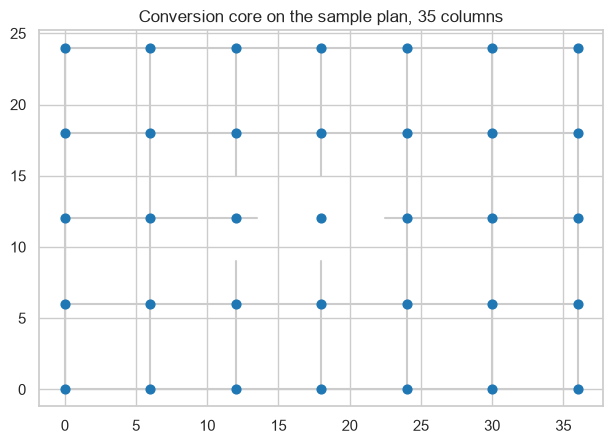

,value
n_columns,35.000
n_lines_x,7.000
n_lines_y,5.000
footprint_x,36.000
footprint_y,24.000
area,864.000
span_x_mean,6.000
span_x_min,6.000
span_x_max,6.000
span_x_std,0.000


In [15]:
# Convert the sample plan and show what one corpus row actually contains.
walls = np.array(json.loads((DATA / "sample_plan.json").read_text())["walls"], float)
columns = parse_walls(walls)
features = rich_features(columns)

fig, ax = plt.subplots(figsize=(7, 4.6))
for x1, y1, x2, y2 in walls:
    ax.plot([x1, x2], [y1, y2], color="0.8", lw=1.5)
ax.scatter(columns[:, 0], columns[:, 1], s=40, color="tab:blue", zorder=3)
ax.set_aspect("equal")
ax.set_title(f"Conversion core on the sample plan, {len(columns)} columns")
plt.tight_layout()
plt.savefig(FIGS / "02_conversion_example.png", dpi=120)
plt.show()

pd.Series(features).round(3).to_frame("value")

## 6. The committed corpus

In [16]:
# What the pipeline produced when it was run over all three archives.
corpus = pd.read_csv(DATA / "features_all.csv")
print(corpus.shape)
corpus.groupby("source").agg(
    arrangements=("n_columns", "size"),
    median_columns=("n_columns", "median"),
    median_regularity=("regularity", "median"),
).round(3)

(29279, 29)


,arrangements,median_columns,median_regularity
source,,,
CubiCasa,4205,11.0,0.462
ResPlan,16812,120.0,0.341
Swiss,8262,40.0,0.466


## 7. The second committed artefact: grid lines

`features_all.csv` holds descriptors, but stage 08 needs the geometry itself
to build alternative grids over the same footprint. `real_grids.csv.gz`
stores exactly that: the x and y grid lines of every parsed building,
translated to the origin and divided by the longer side.

Normalising is what makes the three sources poolable. ResPlan is drawn in
roughly decimetres, Swiss in metres and CubiCasa in SVG pixels, so only
*shape* is comparable, and a normalised grid keeps shape while discarding
the unit.

In [17]:
# How each row is derived from an arrangement: the unique column
# coordinates are the grid lines. Under the derived ground truth a
# column no longer sits at every intersection, so these are the lines
# that carry at least one column rather than the full lattice.
def grid_lines_row(source, entry_id, columns):
    c = np.asarray(columns, float)
    xl, yl = np.unique(c[:, 0]), np.unique(c[:, 1])
    if len(xl) < 3 or len(yl) < 3:            # need at least one interior line
        return None
    xl, yl = xl - xl[0], yl - yl[0]
    scale = max(xl[-1], yl[-1])
    if scale <= 0:
        return None
    xl, yl = xl / scale, yl / scale
    return {"source": source, "id": entry_id,
            "x_lines": " ".join(f"{v:.5f}" for v in xl),
            "y_lines": " ".join(f"{v:.5f}" for v in yl)}


demo = grid_lines_row("sample", 0, columns)
print("x lines:", demo["x_lines"])
print("y lines:", demo["y_lines"])

x lines: 0.00000 0.16667 0.33333 0.50000 0.66667 0.83333 1.00000
y lines: 0.00000 0.16667 0.33333 0.50000 0.66667


In [18]:
# The committed file, as written when the pipeline was run over all three
# archives. 27,972 of the 29,279 arrangements survive; the rest have no
# interior line on one axis and so admit no alternative grid.
real_grids = pd.read_csv(DATA / "real_grids.csv.gz")
print(real_grids.shape)
real_grids.source.value_counts().to_frame("grids")

(27972, 5)


,grids
source,
ResPlan,16818
Swiss,7830
CubiCasa,3324


Two things to carry forward into stage 03:

1. **Unit caveat.** The three sources are drawn in different units, so
   absolute features may only ever be compared within a source.
   intersection by construction, so `n_columns == n_lines_x * n_lines_y`
   always and the ratio is exactly 1.0 in all 29,279 rows. It carries no
   information and must be dropped before modelling.